# HW 18: Link prediction v2

In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from multiprocessing import Pool
import time
import itertools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score,
                             precision_recall_fscore_support,
                             precision_recall_curve,
                             average_precision_score,
                             f1_score)
from sklearn.preprocessing import StandardScaler

In [2]:
import matplotlib
font = {'family': 'sans-serif',
        'weight': 'bold',
        'size': 16}

matplotlib.rc('font', **font)

## Import data

In [3]:
df = pd.read_csv('data/social_network_11.csv')
df.head()

,i,j
0,2106,1
1,2132,1
2,3516,1
3,3881,1
4,10872,1


In [4]:
edges = df.apply(lambda x: (int(x[0]),int(x[1])),
                 axis=1)

In [5]:
e_df = pd.DataFrame(edges)

In [6]:
e_df['edge'] = 1

In [7]:
e_df.columns = ['nodes', 'edge']

## Creating a graph

In [8]:
G = nx.Graph()
G.add_edges_from(edges.values.tolist())

In [9]:
print(nx.info(G))

Name: 
Type: Graph
Number of nodes: 6371
Number of edges: 30607
Average degree:   9.6082


Non-edges:

In [10]:
n_df = pd.Series(nx.non_edges(G))

In [11]:
all_df = pd.DataFrame(n_df)

In [12]:
all_df['edge'] = 0

In [13]:
all_df.columns = ['nodes', 'edge']

Sampling to make the final dataset more balanced:

In [14]:
all_df = all_df.sample(frac=0.03)

Creating a dataframe containing both edges and non-edges

In [15]:
all_df = pd.concat([e_df, all_df], axis=0,
                   ignore_index=True)

In [16]:
all_df.head()

,nodes,edge
0,"(2106, 1)",1
1,"(2132, 1)",1
2,"(3516, 1)",1
3,"(3881, 1)",1
4,"(10872, 1)",1


In [17]:
all_df.shape

(642663, 2)

In [18]:
all_df['edge'].value_counts()

0    607831
1     34832
Name: edge, dtype: int64

### Betweenness centrality

As per https://networkx.github.io/documentation/stable/auto_examples/advanced/plot_parallel_betweenness.html

In [19]:
def chunks(l, n):
    """Divide a list of nodes `l` in `n` chunks"""
    l_c = iter(l)
    while 1:
        x = tuple(itertools.islice(l_c, n))
        if not x:
            return
        yield x


def _betmap(G_normalized_weight_sources_tuple):
    """Pool for multiprocess only accepts functions with one argument.
    This function uses a tuple as its only argument. We use a named tuple for
    python 3 compatibility, and then unpack it when we send it to
    `betweenness_centrality_source`
    """
    return nx.betweenness_centrality_source(*G_normalized_weight_sources_tuple)


def betweenness_centrality_parallel(G, processes=None):
    """Parallel betweenness centrality  function"""
    p = Pool(processes=processes)
    node_divisor = len(p._pool) * 4
    node_chunks = list(chunks(G.nodes(), int(G.order() / node_divisor)))
    num_chunks = len(node_chunks)
    bt_sc = p.map(_betmap,
                  zip([G] * num_chunks,
                      [True] * num_chunks,
                      [None] * num_chunks,
                      node_chunks))

    # Reduce the partial solutions
    bt_c = bt_sc[0]
    for bt in bt_sc[1:]:
        for n in bt:
            bt_c[n] += bt[n]
    return bt_c

In [20]:
print("")
print("Computing betweenness centrality for:")
print(nx.info(G))
print("\tParallel version")
start = time.time()
bt = betweenness_centrality_parallel(G)
print("\t\tTime: %.4F" % (time.time() - start))
print("\t\tBetweenness centrality for node 1: %.5f" % (bt[1]))


Computing betweenness centrality for:
Name: 
Type: Graph
Number of nodes: 6371
Number of edges: 30607
Average degree:   9.6082
	Parallel version
		Time: 63.3065
		Betweenness centrality for node 1: 0.00051


In [21]:
deg_df = pd.DataFrame.from_dict(dict(G.degree), orient='index')
deg_df = deg_df.reset_index()
deg_df.columns=['node','degree']
deg_df['clustering'] = nx.clustering(G, deg_df['node']).values()

In [22]:
deg_df['bt'] = pd.Series(bt)

In [23]:
deg_df.sort_values(by='degree', ascending=False)[:20]

,node,degree,clustering,bt
122,62,506,0.012789,0.001760
123,200,453,0.014066,0.001480
147,1445,285,0.016333,0.000020
46,430,268,0.019900,0.000000
412,106,235,0.028514,0.000546
306,615,193,0.023802,0.000194
407,58,171,0.046233,0.000005
2286,683,168,0.020673,0.000102
279,37,147,0.032989,0.000767
1962,424,145,0.021169,0.000306


Reindexing with node number:

In [24]:
tmp = deg_df.set_index(deg_df['node'])

Adding node features to the graph dataframe:

In [25]:
col_list =  ['degree', 'clustering', 'bt']

In [26]:
all_df['node_1'] = all_df['nodes'].apply(lambda x: x[0])
all_df['node_2'] = all_df['nodes'].apply(lambda x: x[1])

In [27]:
for c in col_list:
    all_df.loc[:, c+'_1'] = tmp.loc[all_df['node_1'], c].values
    all_df.loc[:, c+'_2'] = tmp.loc[all_df['node_2'], c].values

In [28]:
all_df.head()

,nodes,edge,node_1,node_2,degree_1,degree_2,clustering_1,clustering_2,bt_1,bt_2
0,"(2106, 1)",1,2106,1,11,16,0.236364,0.116667,NaN,0.000513
1,"(2132, 1)",1,2132,1,9,16,0.027778,0.116667,2.278751e-04,0.000513
2,"(3516, 1)",1,3516,1,21,16,0.071429,0.116667,4.677991e-08,0.000513
3,"(3881, 1)",1,3881,1,54,16,0.078267,0.116667,5.011842e-04,0.000513
4,"(10872, 1)",1,10872,1,24,16,0.047101,0.116667,6.902598e-07,0.000513


Features characterizing node pairs:

In [29]:
all_df['res_all_index'] = pd.Series(
    nx.resource_allocation_index(G, all_df['nodes'].values))\
        .apply(lambda x:x[2])

In [30]:
all_df['jacc'] = pd.Series(
    nx.jaccard_coefficient(G, all_df['nodes'].values))\
        .apply(lambda x:x[2])

In [31]:
all_df['pref_att'] = pd.Series(
    nx.preferential_attachment(G, all_df['nodes'].values))\
        .apply(lambda x:x[2])

In [32]:
all_df = all_df.fillna(0)

In [33]:
all_df.head()

,nodes,edge,node_1,node_2,degree_1,degree_2,clustering_1,clustering_2,bt_1,bt_2,res_all_index,jacc,pref_att
0,"(2106, 1)",1,2106,1,11,16,0.236364,0.116667,0.000000e+00,0.000513,0.382576,0.125000,176
1,"(2132, 1)",1,2132,1,9,16,0.027778,0.116667,2.278751e-04,0.000513,0.047619,0.041667,144
2,"(3516, 1)",1,3516,1,21,16,0.071429,0.116667,4.677991e-08,0.000513,0.111111,0.027778,336
3,"(3881, 1)",1,3881,1,54,16,0.078267,0.116667,5.011842e-04,0.000513,0.099782,0.044776,864
4,"(10872, 1)",1,10872,1,24,16,0.047101,0.116667,6.902598e-07,0.000513,0.498267,0.142857,384


## Model

In [34]:
feature_col = all_df.columns[(all_df.columns != 'edge') &
                             ((all_df.columns != 'nodes'))]

In [35]:
X_train, X_test, y_train, y_test = \
    train_test_split(all_df[feature_col],
                     all_df['edge'], test_size=0.3)

In [36]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [37]:
clf = LogisticRegression(solver='lbfgs', n_jobs=-1)

In [38]:
clf.fit(X_train, y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='warn', n_jobs=-1, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [39]:
y_score = clf.decision_function(X_test)

In [40]:
f1_score(y_test, clf.predict(X_test))

0.8037690369234141

In [55]:
y_test.shape

(192799,)

In [64]:
((y_test.values == 1) & (y_test.values == clf.predict(X_test))).sum()

7336

In [65]:
(y_test.values == 1).sum()

10365

In [59]:
(y_test == 1).values == (clf.predict(X_test) == 1)

array([ True,  True,  True, ...,  True,  True,  True])

In [50]:
roc_auc_score(y_test, y_score)

0.9592583396639538

In [42]:
average_precision = average_precision_score(y_test, y_score)

In [43]:
precision, recall, thresholds = precision_recall_curve(y_test, y_score)

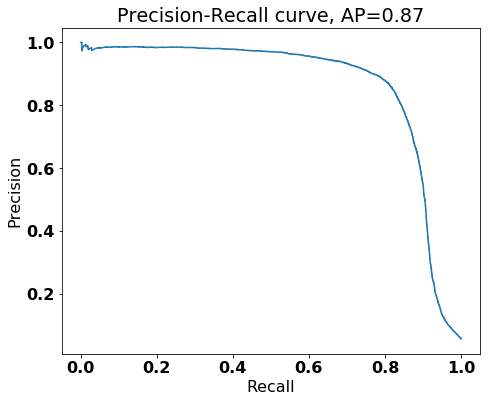

In [44]:
plt.figure(figsize=(7.5, 6))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve, AP={0:0.2f}'.format(average_precision))
plt.show()

In [45]:
sorted(list(zip(clf.coef_.tolist()[0], feature_col)),
       key=lambda x: np.abs(x[0]), reverse=True)

[(-2.972521548828343, 'node_2'),
 (2.394760108810624, 'node_1'),
 (2.004968922865054, 'res_all_index'),
 (0.5877178714174347, 'degree_1'),
 (-0.28548238003963844, 'clustering_1'),
 (-0.2678697910626636, 'pref_att'),
 (0.2447657859307236, 'degree_2'),
 (0.09369005858419012, 'jacc'),
 (0.06983261570056637, 'bt_1'),
 (-0.033480840608753615, 'bt_2'),
 (-0.004764139230617308, 'clustering_2')]